# Loading and Summarizing Data
## FloodNet NYC Tutorial
Author: Mark Bauer

# Summary
We'll demonstrate how to load FloodNet data, as well as basic exploratory data analysis (EDA). Most of the EDA focuses on the Sensor Metadata dataset, as the Flood Events dataset will be further explored in the next notebooks.

# Import Libraries

In [1]:
# libraries
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
import polars as pl
import duckdb
import seaborn as sns
import json
from pathlib import Path

In [2]:
# print versions of packages for reproducibility
libraries = {
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "geopandas": gpd.__version__,
    "matplotlib": matplotlib.__version__,
    "polars": pl.__version__,
    "duckdb": duckdb.__version__,
    "seaborn": sns.__version__,
}

for name, version in libraries.items():
    print(f"{name:10s} {version}")

numpy      2.4.2
pandas     3.0.1
geopandas  1.1.2
matplotlib 3.10.8
polars     1.38.1
duckdb     1.4.4
seaborn    0.13.2


In [3]:
# configure table formatting
pl.Config(tbl_cols=50, tbl_rows=100)

# Load and Inspect Datasets
To review how we downloaded these datasets from NYC Open Data, please refer to the previous notebook **00-download-data.ipynb**.

In [4]:
# list files in data directory
%ls data

Flood Events_Data Dictionary.xlsx
Floodnet_Open_Data_-_Data_Description_03.05.2026.pdf
boroughs.parquet
flood-events.csv
manifest.json
sensor-metadata.csv


In [5]:
# sanity check Manifest file
manifest = json.loads(Path("data/manifest.json").read_text())
manifest

{'datasets': [{'dataset_id': 'kb2e-tjy3',
   'name': 'FloodNet: Sensor Deployment Metadata',
   'data_updated': 'March 17, 2026',
   'downloaded_at': 'April 21, 2026'},
  {'dataset_id': 'aq7i-eu5q',
   'name': 'FloodNet: Street Flooding Events Measured by FloodNet Sensors',
   'data_updated': 'February 26, 2026',
   'downloaded_at': 'April 21, 2026'}]}

In [6]:
# 1) read in flood sensor deployments as dataframe
metadata_path = "data/sensor-metadata.csv"
metadata_df = pl.read_csv(metadata_path, try_parse_dates=True)

# inspect the shape of the data
n_rows, n_columns = metadata_df.shape
print("Metadata dataset:")
print(f"Number of rows: {n_rows}")
print(f"Number of columns: {n_columns}")

# 2) read in flood events as dataframe
events_path = "data/flood-events.csv"
events_df = pl.read_csv(
    events_path,
    # some columns have sparce data, need to expand the row count
    infer_schema_length=100000,
    try_parse_dates=True
)

# inspect the shape of the data
n_rows, n_columns = events_df.shape

print("\nFlood Events dataset:")
print(f"Number of rows: {n_rows:,}")
print(f"Number of columns: {n_columns}")

Metadata dataset:
Number of rows: 380
Number of columns: 16

Flood Events dataset:
Number of rows: 1,887
Number of columns: 13


# 1) Sensor Metadata Dataset

In [7]:
# preview dataframe
metadata_df.head()

sensor_name,sensor_id,date_installed,tidally_influenced,date_removed,street_name,borough,zipcode,community_board,council_district,census_tract,nta,latitude,longitude,lowest_point_height_delta_inches,location
str,str,datetime[μs],str,datetime[μs],str,str,i64,i64,str,i64,str,f64,f64,f64,str
"""BK - Georgia Ave/ Livonia Ave""","""BK-livonia-ave-georgia-ave-2tz…",2026-03-06 00:00:00,"""No""",null,"""Georgia Avenue""","""Brooklyn""",11207,305,"""BK05""",3112600,"""BK0503""",40.664423,-73.895839,7.95,"""POINT (-73.895839 40.664423)"""
"""Q - Roosevelt Ave/Prince St""","""Q-roosevelt-ave-prince-st-2t7s…",2026-02-19 00:00:00,"""No""",null,"""Roosevelt Avenue""","""Queens""",11354,407,"""QN07""",4087100,"""QN0707""",40.758898,-73.832241,6.5,"""POINT (-73.832241 40.758898)"""
"""BK - Lott Ave/Thatford Ave""","""BK-lott-ave-thatford-ave-2tzql…",2026-03-06 00:00:00,"""No""",null,"""Lott Avenue""","""Brooklyn""",11212,316,"""BK16""",3092000,"""BK1602""",40.658076,-73.90676,8.19,"""POINT (-73.90676 40.658076)"""
"""BK - Linden Blvd/Vermont St""","""BK-vermont-st-linden-blvd-2tzq…",2026-03-06 00:00:00,"""No""",null,"""Linden Boulevard""","""Brooklyn""",11207,305,"""BK05""",3110400,"""BK0503""",40.659197,-73.888368,11.42,"""POINT (-73.888368 40.659197)"""
"""BK - Halsey St/Saratoga Ave""","""BK-halsey-st-saratoga-ave-2tzm…",2026-03-06 00:00:00,"""No""",null,"""Halsey Street""","""Brooklyn""",11233,303,"""BK03""",3037700,"""BK0302""",40.685532,-73.917807,6.97,"""POINT (-73.917807 40.685532)"""


In [8]:
# number of missing values per column
(metadata_df.null_count()
    .transpose(
        include_header=True,
        header_name="column",
        column_names=["null_count"]
    )
     .sort(by="null_count", descending=True)
)

column,null_count
str,u32
"""date_removed""",340
"""sensor_name""",0
"""sensor_id""",0
"""date_installed""",0
"""tidally_influenced""",0
"""street_name""",0
"""borough""",0
"""zipcode""",0
"""community_board""",0


In [9]:
# dense preview of dataframe
metadata_df.glimpse(max_items_per_column=3, return_type='frame')

column,dtype,values
str,str,list[str]
"""sensor_name""","""str""","[""'BK - Georgia Ave/ Livonia Ave'"", ""'Q - Roosevelt Ave/Prince St'"", ""'BK - Lott Ave/Thatford Ave'""]"
"""sensor_id""","""str""","[""'BK-livonia-ave-georgia-ave-2tzr8o'"", ""'Q-roosevelt-ave-prince-st-2t7spo'"", ""'BK-lott-ave-thatford-ave-2tzqlc'""]"
"""date_installed""","""datetime[μs]""","[""2026-03-06 00:00:00"", ""2026-02-19 00:00:00"", ""2026-03-06 00:00:00""]"
"""tidally_influenced""","""str""","[""'No'"", ""'No'"", ""'No'""]"
"""date_removed""","""datetime[μs]""","[null, null, null]"
"""street_name""","""str""","[""'Georgia Avenue'"", ""'Roosevelt Avenue'"", ""'Lott Avenue'""]"
"""borough""","""str""","[""'Brooklyn'"", ""'Queens'"", ""'Brooklyn'""]"
"""zipcode""","""i64""","[""11207"", ""11354"", ""11212""]"
"""community_board""","""i64""","[""305"", ""407"", ""316""]"


In [10]:
# summary statistics
metadata_df.describe()

statistic,sensor_name,sensor_id,date_installed,tidally_influenced,date_removed,street_name,borough,zipcode,community_board,council_district,census_tract,nta,latitude,longitude,lowest_point_height_delta_inches,location
str,str,str,str,str,str,str,str,f64,f64,str,f64,str,f64,f64,f64,str
"""count""","""380""","""380""","""380""","""380""","""40""","""380""","""380""",380.0,380.0,"""380""",380.0,"""380""",380.0,380.0,380.0,"""380"""
"""null_count""","""0""","""0""","""0""","""0""","""340""","""0""","""0""",0.0,0.0,"""0""",0.0,"""0""",0.0,0.0,0.0,"""0"""
"""mean""",null,null,"""2024-07-02 05:14:31.578947""",null,"""2024-08-26 21:00:00""",null,null,10934.665789,315.131579,null,3.1140e6,null,40.709983,-73.912776,11.2235,null
"""std""",null,null,null,null,null,null,null,529.330499,114.802658,null,1.1610e6,null,0.085743,0.097794,8.307998,null
"""min""","""BK - Farragut Rd/ Rockaway Pk…","""BK-10th-ave-76th-st-1umos0""","""2020-10-05 00:00:00""","""No""","""2021-12-10 00:00:00""","""100th Street""","""Bronx""",10002.0,101.0,"""BK01""",1.0008e6,"""BK0101""",40.531504,-74.206958,0.0,"""POINT (-73.729558 40.65572)"""
"""25%""",null,null,"""2024-01-12 00:00:00""",null,"""2023-10-12 00:00:00""",null,null,10459.0,210.0,null,2.0356e6,null,40.650531,-73.970166,7.44,null
"""50%""",null,null,"""2024-08-08 00:00:00""",null,"""2024-12-13 00:00:00""",null,null,11213.0,313.0,null,3.059e6,null,40.698449,-73.917187,9.45,null
"""75%""",null,null,"""2025-03-27 00:00:00""",null,"""2025-08-21 00:00:00""",null,null,11368.0,410.0,null,4.0473e6,null,40.763964,-73.839728,11.89,null
"""max""","""SI - Willow Rd E/Nina Ave""","""SI-willow-rd-e-nina-ave-0xx2c0""","""2026-03-06 00:00:00""","""Yes""","""2025-11-25 00:00:00""","""Wythe Avenue""","""Staten Island""",11693.0,503.0,"""SI03""",5.029105e6,"""SI0304""",40.90418,-73.729558,64.96,"""POINT (-74.206958 40.531504)"""


In [11]:
# confirm sensor IDs and names are unique
(metadata_df.filter(pl.col("date_removed").is_null())
    .select([
        pl.col("sensor_id").is_duplicated().sum().alias("sensor_id_duplicates"),
        pl.col("sensor_name").is_duplicated().sum().alias("sensor_name__duplicates")
    ])
)

sensor_id_duplicates,sensor_name__duplicates
u32,u32
0,0


## Date Installed or Removed

In [12]:
n_active = metadata_df.filter(pl.col("date_removed").is_null()).height
print(f"Number of active sensors: {n_active}")

n_removed = metadata_df.filter(pl.col("date_removed").is_not_null()).height
print(f"Number of sensors removed: {n_removed}")

Number of active sensors: 340
Number of sensors removed: 40


In [13]:
# sensor date statistics
metadata_df.select(
    pl.col(["date_installed", "date_removed"]).min().name.suffix("_min"),
    pl.col(["date_installed", "date_removed"]).max().name.suffix("_max"),
)

date_installed_min,date_removed_min,date_installed_max,date_removed_max
datetime[μs],datetime[μs],datetime[μs],datetime[μs]
2020-10-05 00:00:00,2021-12-10 00:00:00,2026-03-06 00:00:00,2025-11-25 00:00:00


In [14]:
date_min = metadata_df.get_column("date_installed").min()
date_max = metadata_df.get_column("date_installed").max()

date_range = (date_max - date_min).days

print(f"FloodNet installations span {date_min} to {date_max} ({date_range / 365:.1f} years).")

FloodNet installations span 2020-10-05 00:00:00 to 2026-03-06 00:00:00 (5.4 years).


In [15]:
# oldest sensor in network
(metadata_df.sort(by="date_installed")
    .head(1)
    .transpose(
        include_header=True,
        header_name="column", column_names=["value"])
)

column,value
str,str
"""sensor_name""","""BK - Hoyt St/5th St"""
"""sensor_id""","""BK-hoyt-st-5th-st-007sk0"""
"""date_installed""","""2020-10-05 00:00:00.000000"""
"""tidally_influenced""","""No"""
"""date_removed""",null
"""street_name""","""Hoyt Street"""
"""borough""","""Brooklyn"""
"""zipcode""","""11231"""
"""community_board""","""306"""


In [16]:
# newest sensor in network
(metadata_df.sort(by="date_installed", descending=True)
    .head(1)
    .transpose(
        include_header=True,
        header_name="column", column_names=["value"])
)

column,value
str,str
"""sensor_name""","""BK - Georgia Ave/ Livonia Ave"""
"""sensor_id""","""BK-livonia-ave-georgia-ave-2tz…"
"""date_installed""","""2026-03-06 00:00:00.000000"""
"""tidally_influenced""","""No"""
"""date_removed""",null
"""street_name""","""Georgia Avenue"""
"""borough""","""Brooklyn"""
"""zipcode""","""11207"""
"""community_board""","""305"""


## Sensor Ground Height Above Local Low Point
Review distribution of values and potential outliers.

**lowest_point_height_delta_inches:**

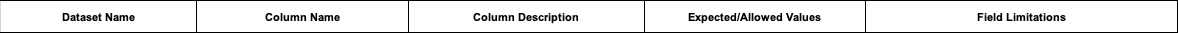
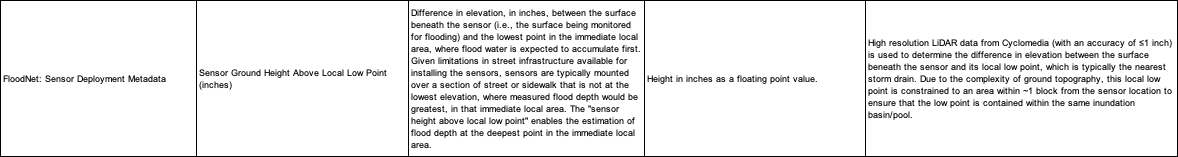

**Source: data dictionary**

In [17]:
# summary staistics
metadata_df.get_column("lowest_point_height_delta_inches").describe()

statistic,value
str,f64
"""count""",380.0
"""null_count""",0.0
"""mean""",11.2235
"""std""",8.307998
"""min""",0.0
"""25%""",7.44
"""50%""",9.45
"""75%""",11.89
"""max""",64.96


In [18]:
# create histogram
metadata_df.get_column("lowest_point_height_delta_inches").hist()

breakpoint,category,count
f64,cat,u32
6.496,"""[0.0, 6.496]""",62
12.992,"""(6.496, 12.992]""",242
19.488,"""(12.992, 19.488]""",48
25.984,"""(19.488, 25.984]""",10
32.48,"""(25.984, 32.48]""",8
38.976,"""(32.48, 38.976]""",3
45.472,"""(38.976, 45.472]""",0
51.968,"""(45.472, 51.968]""",2
58.464,"""(51.968, 58.464]""",2


<Axes: xlabel='lowest_point_height_delta_inches', ylabel='Count'>

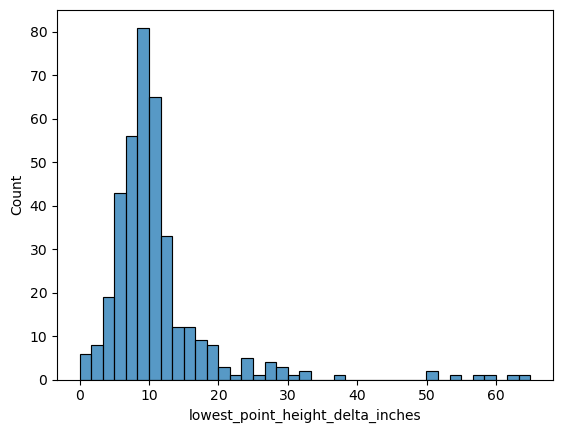

In [19]:
# histogram figure
sns.histplot(data=metadata_df, x="lowest_point_height_delta_inches")

In [20]:
# identify potential outliers with Interquartile Range (IQR)
col = "lowest_point_height_delta_inches"
q1 = metadata_df.get_column(col).quantile(0.25)
q3 = metadata_df.get_column(col).quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print(f"Q1:    {q1}")
print(f"Q3:    {q3}")
print(f"IQR:   {iqr}")

# Flag outliers
outliers = metadata_df.filter(
    (pl.col(col) < lower) | (pl.col(col) > upper)
)
print(f"\nNumber of Potential Outliers: {len(outliers)}")
print(f"Lower bound: {lower}")
print(f"Upper bound: {upper}")

Q1:    7.44
Q3:    11.89
IQR:   4.45

Number of Potential Outliers: 38
Lower bound: 0.7649999999999997
Upper bound: 18.565


In [21]:
# preview potential outliers for upper limit
# sorted by lowest local point desc.
(metadata_df.filter(pl.col(col) > upper)
    .sort(by=col, descending=True)
    .head()
)

sensor_name,sensor_id,date_installed,tidally_influenced,date_removed,street_name,borough,zipcode,community_board,council_district,census_tract,nta,latitude,longitude,lowest_point_height_delta_inches,location
str,str,datetime[μs],str,datetime[μs],str,str,i64,i64,str,i64,str,f64,f64,f64,str
"""BK - Van Brunt St/Reed St""","""BK-van-brunt-st-reed-st-0pzyg0""",2022-02-18 00:00:00,"""No""",2022-12-27 00:00:00,"""Van Brunt Street""","""Brooklyn""",11231,306,"""BK06""",3005301,"""BK0601""",40.674602,-74.01607,64.96,"""POINT (-74.01607 40.674602)"""
"""BX - Sheridan Bl/173rd St""","""BX-sheridan-bl-173rd-st-0pmx00""",2022-02-11 00:00:00,"""No""",null,"""Sheridan Boulevard, State Rout…","""Bronx""",10459,203,"""BX03""",2015700,"""BX0303""",40.833601,-73.883273,62.8,"""POINT (-73.883273 40.833601)"""
"""M - E 116th St/FDR Drive""","""M-e-111th-st-a-new-st-1yjl00""",2024-07-03 00:00:00,"""No""",2024-12-13 00:00:00,"""East 110th Street""","""Manhattan""",10029,111,"""MN11""",1016200,"""MN1101""",40.792351,-73.936903,59.65,"""POINT (-73.936903 40.792351)"""
"""Q - 79th St/151st Ave""","""Q-79th-st-151-ave-1w2go0""",2024-05-16 00:00:00,"""No""",null,"""79th Street""","""Queens""",11414,410,"""QN10""",4006202,"""QN1003""",40.667256,-73.855389,56.69,"""POINT (-73.855389 40.667256)"""
"""Q - 48th Ave/108th St""","""Q-48th-ave-108th-st-20pto0""",2024-08-14 00:00:00,"""No""",null,"""108th Street""","""Queens""",11368,404,"""QN04""",4041500,"""QN0402""",40.746128,-73.856278,54.49,"""POINT (-73.856278 40.746128)"""


We'll return to these potential outliers when we join to the flood events dataset.

# NYC Borough Boundaries

In [22]:
# read in NYC Boroughs geometries from NYC Open Data
path = "data/boroughs.parquet"
boro_gdf = gpd.read_parquet(path)

boro_gdf.head()

,borocode,boroname,shape_area,shape_leng,geometry
0,5,Staten Island,1623618358.46,325912.288988,"MULTIPOLYGON (((-74.05051 40.56642, -74.05047 ..."
1,1,Manhattan,636631650.451,359537.866079,"MULTIPOLYGON (((-74.01093 40.68449, -74.01193 ..."
2,2,Bronx,1187199300.36,463147.071867,"MULTIPOLYGON (((-73.89681 40.79581, -73.89694 ..."
3,3,Brooklyn,1934462607.43,726953.044632,"MULTIPOLYGON (((-73.86327 40.58388, -73.86381 ..."
4,4,Queens,3041419178.99,887905.076018,"MULTIPOLYGON (((-73.82645 40.59053, -73.82642 ..."


In [23]:
# confirm CRS
boro_gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [24]:
# generate geometry from x, y points
geometry = gpd.points_from_xy(
    metadata_df['longitude'],
    metadata_df['latitude']
)

# these coordinates are stored in 4326
crs = 4326

# create geodataframe
metadata_gdf = gpd.GeoDataFrame(
    metadata_df.to_pandas(),
    geometry=geometry,
    crs=crs
)

# sanity checks
print(f'shape of data: {metadata_gdf.shape}')
print(metadata_gdf.crs)

# preview data
metadata_gdf['geometry'].head()

shape of data: (380, 17)
EPSG:4326


0    POINT (-73.89584 40.66442)
1     POINT (-73.83224 40.7589)
2    POINT (-73.90676 40.65808)
3     POINT (-73.88837 40.6592)
4    POINT (-73.91781 40.68553)
Name: geometry, dtype: geometry

## Sensor Locations

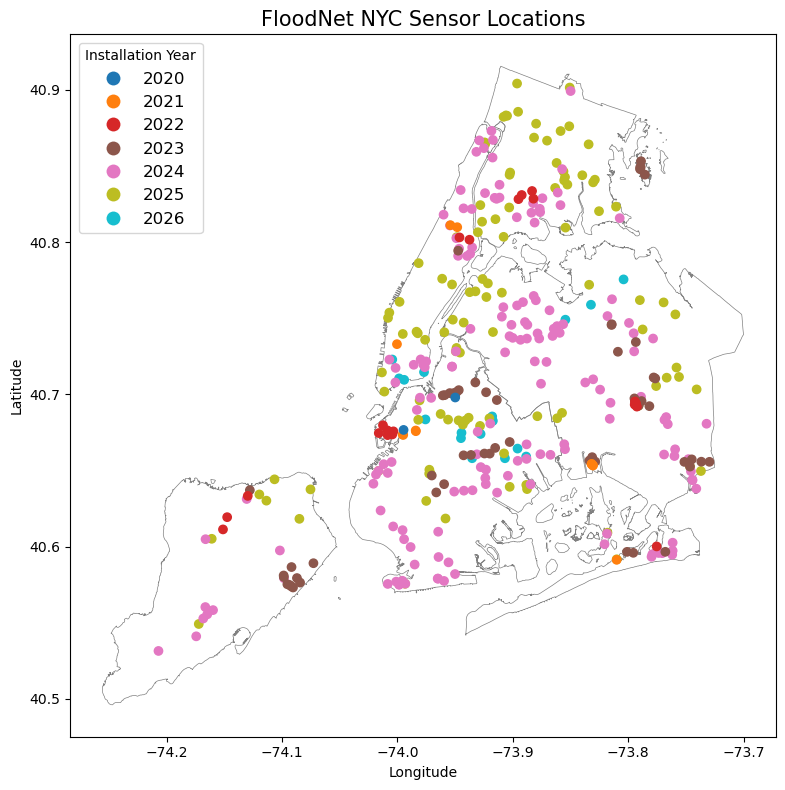

In [25]:
# create figure
fig, ax = plt.subplots(figsize=(8, 8))

# sort on date ascending, we want to see old sensors on top
plot_gdf = metadata_gdf.sort_values(by='date_installed', ascending=False)

# sensors plot
plot_gdf.plot(
    column=plot_gdf['date_installed'].dt.year.astype(str),
    categorical=True,
    ax=ax,
    legend=True,
    legend_kwds={"title": "Installation Year", "loc":"upper left", "fontsize": "large"},
)

# borough plot
boro_gdf.plot(
    ax=ax,
    facecolor="None", linewidth=.5, edgecolor="gray",
    zorder=0
)

# figure labels
plt.title("FloodNet NYC Sensor Locations", fontsize=15)
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# tight layout
plt.tight_layout()

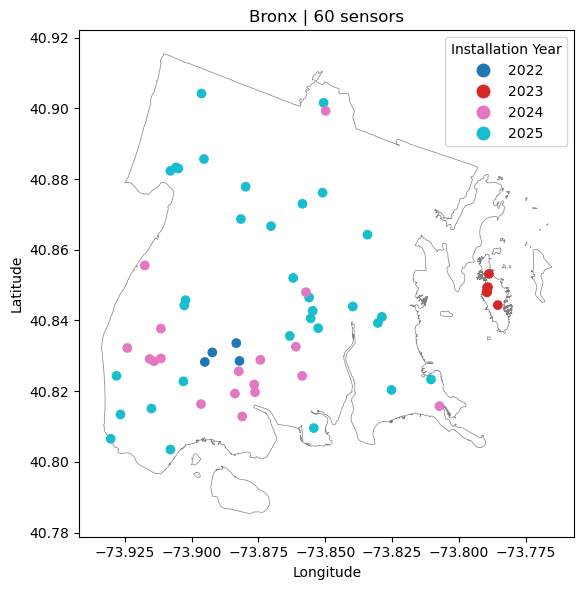

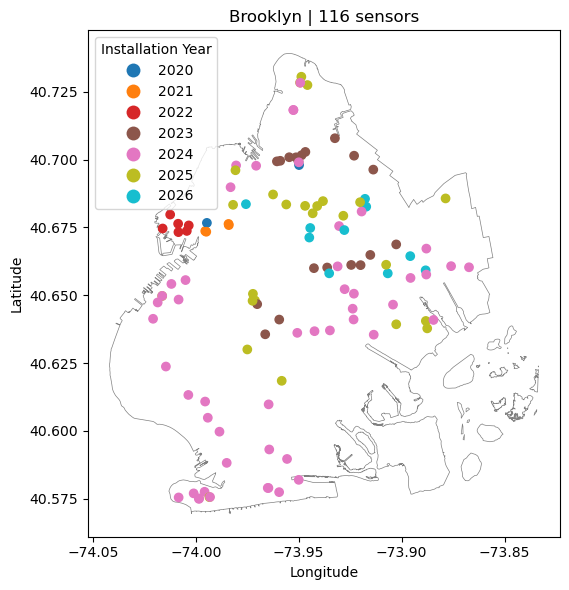

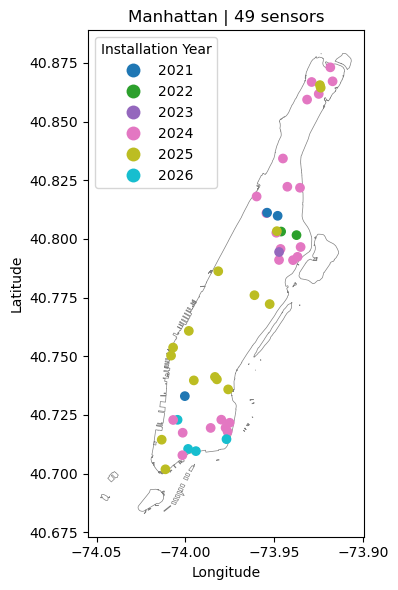

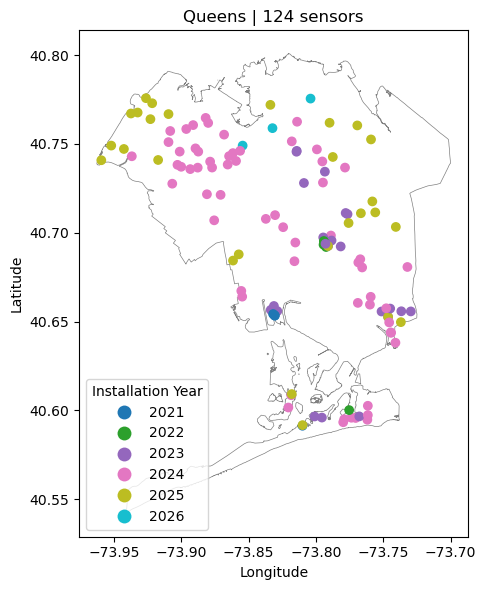

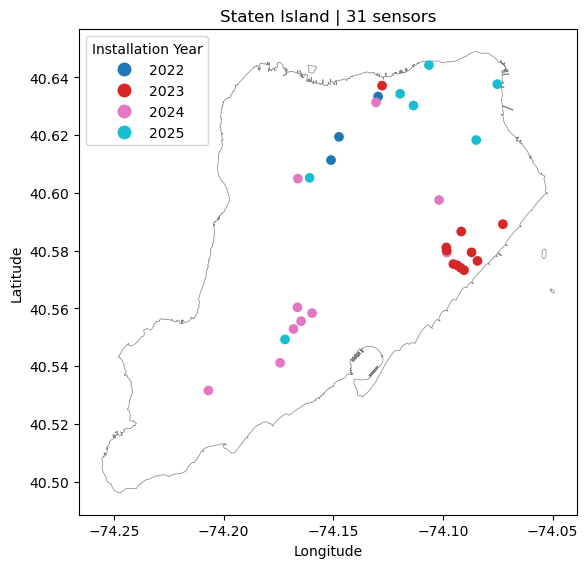

In [26]:
# tighter view per borough

# plot sensors by borough
boroughs = metadata_gdf['borough'].sort_values().unique()

for borough in boroughs:

    fig, ax = plt.subplots(figsize=(6, 6))

    # sensors plot
    plot_df = metadata_gdf.loc[metadata_gdf['borough'] == borough]
    plot_df.plot(
        column=plot_df['date_installed'].dt.year.astype(str),
        categorical=True,
        ax=ax,
        legend=True,
        legend_kwds={"title": "Installation Year"},
    )

    # borough plot
    (boro_gdf.loc[boro_gdf['boroname'] == borough]
        .plot(
            ax=ax,
            facecolor="None", linewidth=.5, edgecolor="gray",
            zorder=0
        )
    )

    # figure labels
    ax.set_title(f"{borough} | {plot_df.shape[0]} sensors")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    
    plt.tight_layout()

## Active Sensors

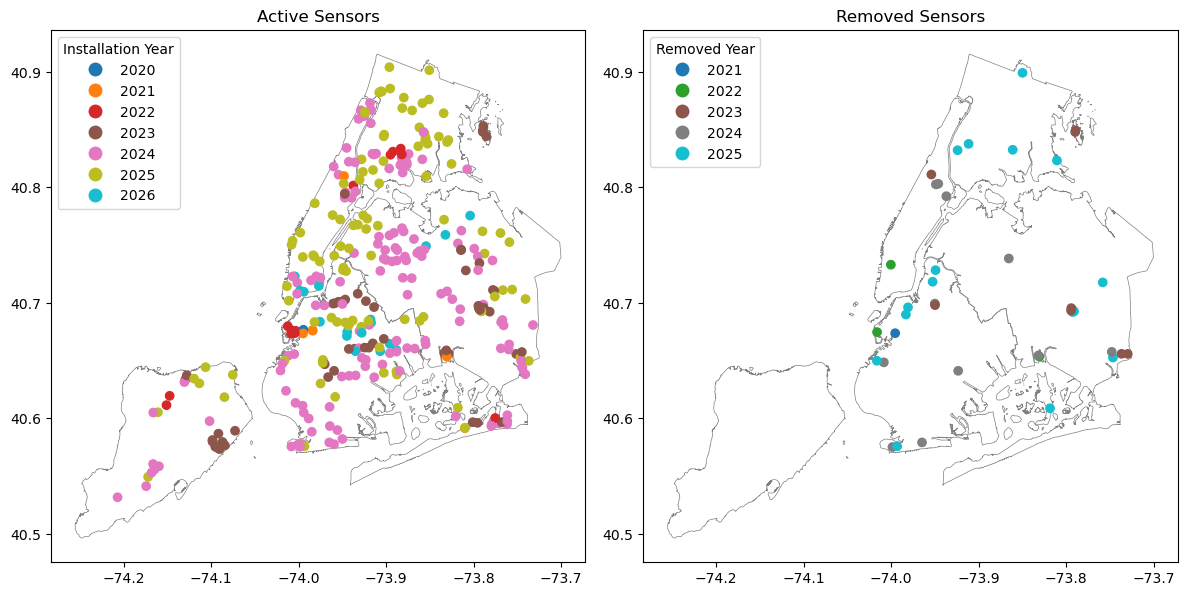

In [27]:
# create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 12))

# active sensors
sensors_active_df = (
    metadata_gdf.loc[metadata_gdf['date_removed'].isna()]
)

sensors_active_df.plot(
    ax=ax1,
    column=sensors_active_df['date_installed'].dt.year.astype(str),
    categorical=True,
    legend=True,
    legend_kwds={"title": "Installation Year"}
)

# sensors removed
sensors_removed_df = (
    metadata_gdf.loc[~metadata_gdf['date_removed'].isna()]
)
 
sensors_removed_df.plot(
    ax=ax2,
    column=sensors_removed_df['date_removed'].dt.year.astype(str),
    categorical=True,
    legend=True,
    legend_kwds={"title": "Removed Year"}
)

# borough plot
boro_gdf.plot(
    ax=ax1,
    facecolor="None", linewidth=.5, edgecolor="gray",
    zorder=0
)

# borough plot
boro_gdf.plot(
    ax=ax2,
    facecolor="None", linewidth=.5, edgecolor="gray",
    zorder=0
)

# figure labels
ax1.set_title("Active Sensors")
ax2.set_title("Removed Sensors")

plt.tight_layout()

## New Sensors by Year
Plotting additional new sensors per year, not cumulative count.

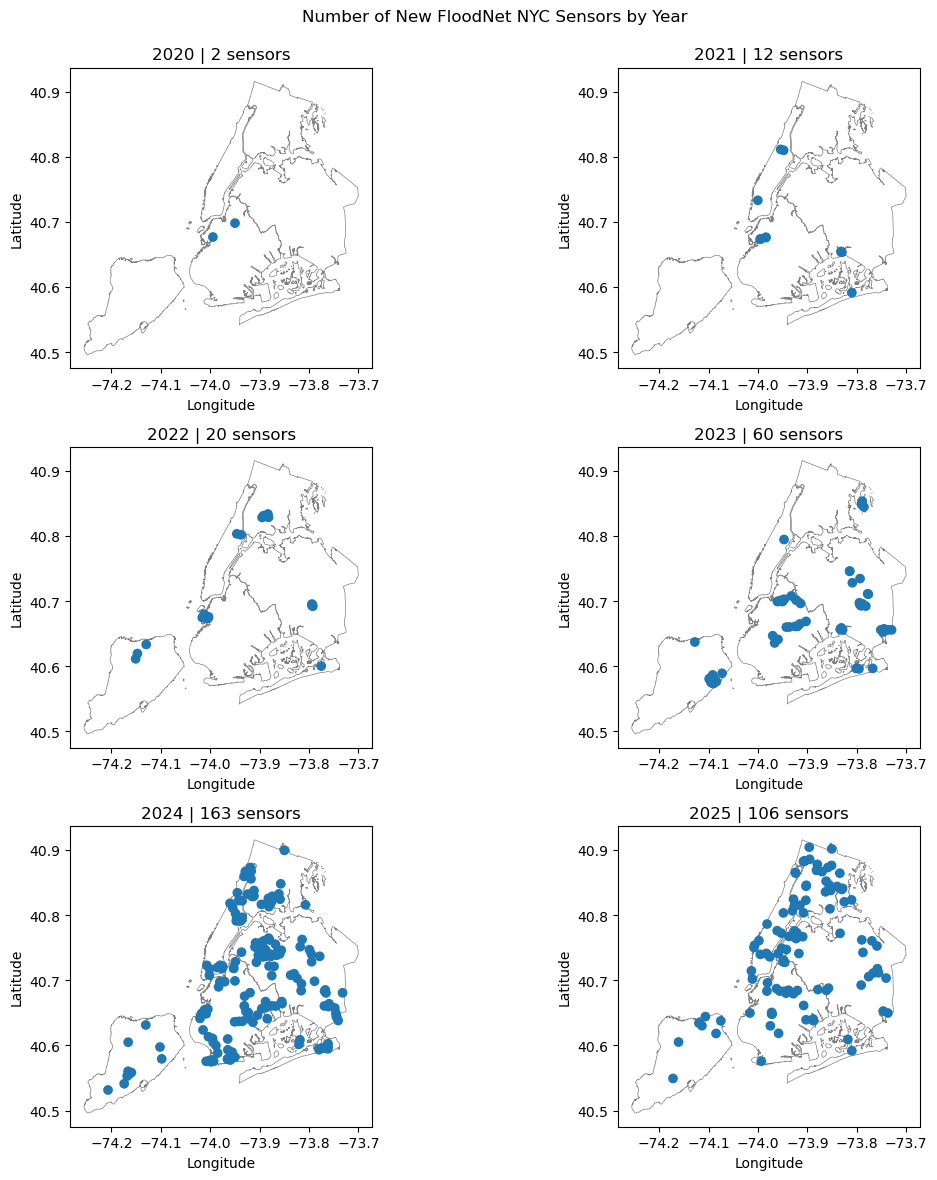

In [28]:
# create figure
fig, axs = plt.subplots(3, 2, figsize=(12, 12))

# plot only active sensors
years = metadata_gdf['date_installed'].dt.year.sort_values().unique()

for year, ax in zip(years, axs.flat):

    # sensors plot
    plot_df = metadata_gdf.loc[
        metadata_gdf['date_installed'].dt.year == int(year)
    ]
    plot_df.plot(
        column=plot_df['date_installed'].dt.year.astype(str),
        categorical=True,
        ax=ax,
    )

    # borough plot
    boro_gdf.plot(
        ax=ax,
        facecolor="None", linewidth=.5, edgecolor="gray",
        zorder=0
    )

    # figure labels
    ax.set_title(f"{year} | {plot_df.shape[0]} sensors")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    
fig.suptitle("Number of New FloodNet NYC Sensors by Year\n")    
fig.tight_layout()    

## Tidally Influenced Sensors

In [29]:
# tidally influence
metadata_df.get_column("tidally_influenced").value_counts()

tidally_influenced,count
str,u32
"""Yes""",48
"""No""",332


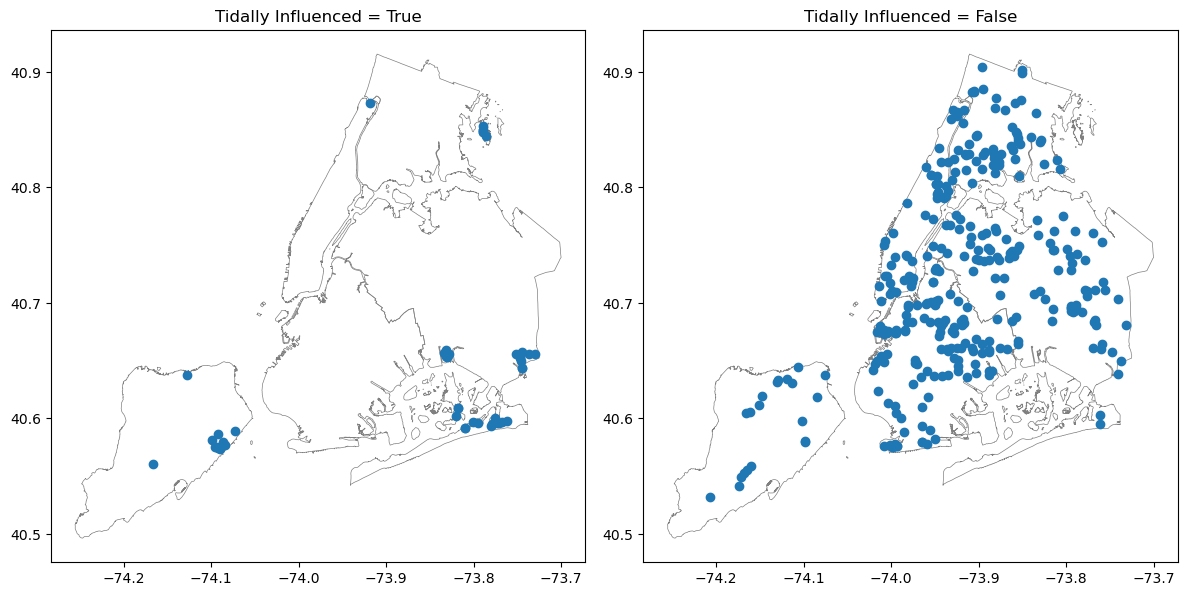

In [30]:
# create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 12))

# sensors plot
(metadata_gdf.loc[metadata_gdf['tidally_influenced'] == "Yes"]
 .plot(ax=ax1)
)

# borough plot
boro_gdf.plot(
    ax=ax1,
    facecolor="None", linewidth=.5, edgecolor="gray",
    zorder=0
)

# sensors plot
(metadata_gdf.loc[metadata_gdf['tidally_influenced'] == "No"]
 .plot(ax=ax2)
)

# borough plot
boro_gdf.plot(
    ax=ax2,
    facecolor="None", linewidth=.5, edgecolor="gray",
    zorder=0
)

# figure labels
ax1.set_title("Tidally Influenced = True")
ax2.set_title("Tidally Influenced = False")

plt.tight_layout()

## Sensor Ground Height Above Local Low Point

In [31]:
# lowest_point_height_delta_inches
metadata_df.select(pl.col('lowest_point_height_delta_inches')).describe()

statistic,lowest_point_height_delta_inches
str,f64
"""count""",380.0
"""null_count""",0.0
"""mean""",11.2235
"""std""",8.307998
"""min""",0.0
"""25%""",7.44
"""50%""",9.45
"""75%""",11.89
"""max""",64.96


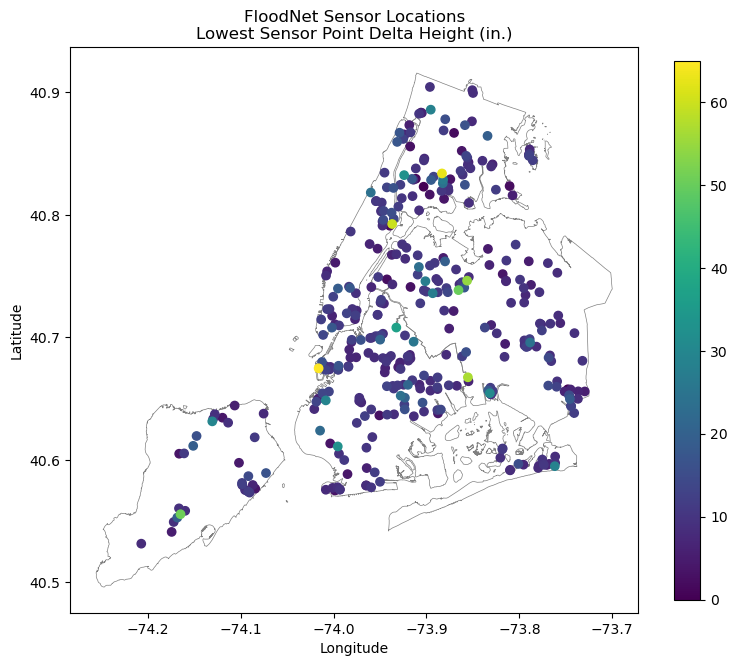

In [32]:
# create figure
fig, ax = plt.subplots(figsize=(8, 8))

# highest values on top of map
plot_gdf = metadata_gdf.sort_values(by='lowest_point_height_delta_inches')

# sensors plot
plot_gdf.plot(
    column="lowest_point_height_delta_inches",
    ax=ax,
    legend=True,
    legend_kwds={
        "shrink": 0.70, # Shrinks the colorbar to 50% of the axis height
    },
)

# borough plot
boro_gdf.plot(
    ax=ax,
    facecolor="None", linewidth=.5, edgecolor="gray",
    zorder=0
)

# figure aesthetics
plt.title("FloodNet Sensor Locations\nLowest Sensor Point Delta Height (in.)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# tight layout
plt.tight_layout()

# 2) Flood Events Dataset

In [33]:
# preview the first few rows
events_df.head()

sensor_name,sensor_id,flood_start_time,flood_end_time,max_depth_inches,onset_time_mins,drain_time_mins,duration_mins,duration_above_4_inches_mins,duration_above_12_inches_mins,duration_above_24_inches_mins,flood_profile_depth_inches,flood_profile_time_secs
str,str,datetime[μs],datetime[μs],f64,f64,f64,f64,f64,f64,f64,str,str
"""Q - Beach 84 St""","""Q-beach-84-st-0me680""",2023-10-30 12:00:39,2023-10-30 16:38:19,17.72,133.86,143.81,277.66,211.41,103.6,0.0,"""[0.00, 0.87, 1.02, 1.38, 1.93,…","""[0, 1008, 1134, 1512, 1826, 20…"
"""BX - 1st St/Avenue A""","""BX-1st-st-avenue-a-1zby90""",2025-04-26 23:17:20,2025-04-27 11:55:34,6.18,27.95,730.29,758.24,132.81,0.0,0.0,"""[0.00, 0.71, 1.38, 1.38, 1.38,…","""[0, 64, 129, 132, 196, 260, 32…"
"""Q - Beach 35 St/Beach Channel …","""Q-beach-35-st-beach-channel-dr…",2024-02-09 11:41:01,2024-02-09 13:20:57,5.31,54.51,45.43,99.94,45.09,0.0,0.0,"""[0.00, 0.43, 0.63, 0.71, 0.94,…","""[0, 68, 136, 204, 273, 341, 40…"
"""BX - Tibbett Ave/W 234th St""","""BX-w-234th-st-tibbett-ave-2cak…",2025-08-20 21:05:19,2025-08-21 00:46:19,1.18,80.0,141.0,221.0,0.0,0.0,0.0,"""[0.00, 0.43, 0.47, 0.47, 0.51,…","""[0, 60, 120, 180, 240, 300, 36…"
"""Q - Davenport Ct 1""","""Q-davenport-ct-1-07zks0""",2024-01-10 00:39:25,2024-01-10 02:30:40,2.09,59.82,51.43,111.25,0.0,0.0,0.0,"""[0.00, 0.47, 0.47, 0.43, 0.43,…","""[0, 63, 127, 189, 252, 315, 37…"


In [34]:
# preview count of flood events
n_events = events_df.get_column("sensor_id").len()
print(f"Number of flood events from all sensors: {n_events:,}")

sensors_unique = events_df.get_column("sensor_id").n_unique()
print(f"Number of unique sensors with recorded flooding: {sensors_unique}")

Number of flood events from all sensors: 1,887
Number of unique sensors with recorded flooding: 168


In [35]:
# inspect column information and data types
# note: flood profiles include a large number of values
events_df.glimpse(max_items_per_column=5, return_type='frame')

column,dtype,values
str,str,list[str]
"""sensor_name""","""str""","[""'Q - Beach 84 St'"", ""'BX - 1st St/Avenue A'"", … ""'Q - Davenport Ct 1'""]"
"""sensor_id""","""str""","[""'Q-beach-84-st-0me680'"", ""'BX-1st-st-avenue-a-1zby90'"", … ""'Q-davenport-ct-1-07zks0'""]"
"""flood_start_time""","""datetime[μs]""","[""2023-10-30 12:00:39"", ""2025-04-26 23:17:20"", … ""2024-01-10 00:39:25""]"
"""flood_end_time""","""datetime[μs]""","[""2023-10-30 16:38:19"", ""2025-04-27 11:55:34"", … ""2024-01-10 02:30:40""]"
"""max_depth_inches""","""f64""","[""17.72"", ""6.18"", … ""2.09""]"
"""onset_time_mins""","""f64""","[""133.86"", ""27.95"", … ""59.82""]"
"""drain_time_mins""","""f64""","[""143.81"", ""730.29"", … ""51.43""]"
"""duration_mins""","""f64""","[""277.66"", ""758.24"", … ""111.25""]"
"""duration_above_4_inches_mins""","""f64""","[""211.41"", ""132.81"", … ""0.0""]"


In [36]:
# number of missing values per column (sorted descending)
events_df.null_count().transpose(include_header=True, column_names=["null_count"])

column,null_count
str,u32
"""sensor_name""",0
"""sensor_id""",0
"""flood_start_time""",0
"""flood_end_time""",0
"""max_depth_inches""",0
"""onset_time_mins""",0
"""drain_time_mins""",0
"""duration_mins""",0
"""duration_above_4_inches_mins""",0


In [37]:
# summary statistics of numeric columns
events_df.describe()

statistic,sensor_name,sensor_id,flood_start_time,flood_end_time,max_depth_inches,onset_time_mins,drain_time_mins,duration_mins,duration_above_4_inches_mins,duration_above_12_inches_mins,duration_above_24_inches_mins,flood_profile_depth_inches,flood_profile_time_secs
str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,str,str
"""count""","""1887""","""1887""","""1887""","""1887""",1887.0,1887.0,1887.0,1887.0,1887.0,1887.0,1887.0,"""1887""","""1887"""
"""null_count""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""","""0"""
"""mean""",null,null,"""2024-06-21 22:45:11.897721""","""2024-06-22 01:39:25.863804""",5.672173,65.591484,108.641569,174.232899,54.723715,8.77318,0.80753,null,null
"""std""",null,null,null,null,4.943472,82.997968,177.082204,221.591563,82.513816,38.750084,10.227863,null,null
"""min""","""BK - 16th Ave/80th St""","""BK-10th-ave-76th-st-1umos0""","""2020-11-16 01:41:17""","""2020-11-16 04:12:05""",0.47,1.0,3.0,5.0,0.0,0.0,0.0,"""[0.00, 0.00, 0.00, 0.00, 0.00,…","""[0, 1007, 1069, 2014, 3022, 36…"
"""25%""",null,null,"""2023-10-15 00:02:56""","""2023-10-15 04:33:47""",2.36,23.27,36.73,70.48,0.0,0.0,0.0,null,null
"""50%""",null,null,"""2024-07-28 20:55:37""","""2024-07-28 23:16:43""",4.21,47.39,62.07,133.76,8.23,0.0,0.0,null,null
"""75%""",null,null,"""2025-07-02 05:37:28""","""2025-07-02 07:43:16""",7.24,88.24,121.42,206.52,90.53,0.0,0.0,null,null
"""max""","""SI - Willow Rd E/Nina Ave""","""SI-willow-rd-e-nina-ave-0xx2c0""","""2026-01-07 15:14:27""","""2026-01-07 17:14:27""",40.87,1647.58,2782.15,3485.99,749.86,516.27,245.3,"""[3.43, 3.98, 4.57, 5.12, 5.47,…","""[63, 126, 189, 252, 315, 378, …"


## Datetime Conversion

In [38]:
# convert date columns to local datetime
events_df = events_df.with_columns(
    pl.col("flood_start_time")
        .dt.convert_time_zone(time_zone='America/New_York')
        .alias("flood_start_time_est"),
    pl.col("flood_end_time")
        .dt.convert_time_zone(time_zone='America/New_York')
        .alias("flood_end_time_est")
)

# preview new dtypes
events_df.head()

sensor_name,sensor_id,flood_start_time,flood_end_time,max_depth_inches,onset_time_mins,drain_time_mins,duration_mins,duration_above_4_inches_mins,duration_above_12_inches_mins,duration_above_24_inches_mins,flood_profile_depth_inches,flood_profile_time_secs,flood_start_time_est,flood_end_time_est
str,str,datetime[μs],datetime[μs],f64,f64,f64,f64,f64,f64,f64,str,str,"datetime[μs, America/New_York]","datetime[μs, America/New_York]"
"""Q - Beach 84 St""","""Q-beach-84-st-0me680""",2023-10-30 12:00:39,2023-10-30 16:38:19,17.72,133.86,143.81,277.66,211.41,103.6,0.0,"""[0.00, 0.87, 1.02, 1.38, 1.93,…","""[0, 1008, 1134, 1512, 1826, 20…",2023-10-30 08:00:39 EDT,2023-10-30 12:38:19 EDT
"""BX - 1st St/Avenue A""","""BX-1st-st-avenue-a-1zby90""",2025-04-26 23:17:20,2025-04-27 11:55:34,6.18,27.95,730.29,758.24,132.81,0.0,0.0,"""[0.00, 0.71, 1.38, 1.38, 1.38,…","""[0, 64, 129, 132, 196, 260, 32…",2025-04-26 19:17:20 EDT,2025-04-27 07:55:34 EDT
"""Q - Beach 35 St/Beach Channel …","""Q-beach-35-st-beach-channel-dr…",2024-02-09 11:41:01,2024-02-09 13:20:57,5.31,54.51,45.43,99.94,45.09,0.0,0.0,"""[0.00, 0.43, 0.63, 0.71, 0.94,…","""[0, 68, 136, 204, 273, 341, 40…",2024-02-09 06:41:01 EST,2024-02-09 08:20:57 EST
"""BX - Tibbett Ave/W 234th St""","""BX-w-234th-st-tibbett-ave-2cak…",2025-08-20 21:05:19,2025-08-21 00:46:19,1.18,80.0,141.0,221.0,0.0,0.0,0.0,"""[0.00, 0.43, 0.47, 0.47, 0.51,…","""[0, 60, 120, 180, 240, 300, 36…",2025-08-20 17:05:19 EDT,2025-08-20 20:46:19 EDT
"""Q - Davenport Ct 1""","""Q-davenport-ct-1-07zks0""",2024-01-10 00:39:25,2024-01-10 02:30:40,2.09,59.82,51.43,111.25,0.0,0.0,0.0,"""[0.00, 0.47, 0.47, 0.43, 0.43,…","""[0, 63, 127, 189, 252, 315, 37…",2024-01-09 19:39:25 EST,2024-01-09 21:30:40 EST


# 3) Join Sensor Metadata and Flood Events Datasets

In [39]:
# merge flood sensor events with sensor metadata
merged_df = events_df.join(
    metadata_df.drop("sensor_name"),
    on="sensor_id",
    how="left",  # keep all events, even if metadata is missing
)

# inspect the shape of the merged data
n_rows, n_columns = merged_df.shape
print(f"Number of rows of merged df: {n_rows:,}")
print(f"Number of columns: {n_columns}")

# events without matching metadata
missing_meta_count = merged_df["sensor_id"].null_count()
print(f"Events without matching sensor metadata: {missing_meta_count}\n")

# preview the first few rows
merged_df.head()

Number of rows of merged df: 1,887
Number of columns: 29
Events without matching sensor metadata: 0



sensor_name,sensor_id,flood_start_time,flood_end_time,max_depth_inches,onset_time_mins,drain_time_mins,duration_mins,duration_above_4_inches_mins,duration_above_12_inches_mins,duration_above_24_inches_mins,flood_profile_depth_inches,flood_profile_time_secs,flood_start_time_est,flood_end_time_est,date_installed,tidally_influenced,date_removed,street_name,borough,zipcode,community_board,council_district,census_tract,nta,latitude,longitude,lowest_point_height_delta_inches,location
str,str,datetime[μs],datetime[μs],f64,f64,f64,f64,f64,f64,f64,str,str,"datetime[μs, America/New_York]","datetime[μs, America/New_York]",datetime[μs],str,datetime[μs],str,str,i64,i64,str,i64,str,f64,f64,f64,str
"""Q - Beach 84 St""","""Q-beach-84-st-0me680""",2023-10-30 12:00:39,2023-10-30 16:38:19,17.72,133.86,143.81,277.66,211.41,103.6,0.0,"""[0.00, 0.87, 1.02, 1.38, 1.93,…","""[0, 1008, 1134, 1512, 1826, 20…",2023-10-30 08:00:39 EDT,2023-10-30 12:38:19 EDT,2021-12-10 00:00:00,"""Yes""",null,"""Beach 84th Street""","""Queens""",11693,414,"""QN14""",4094202,"""QN1402""",40.59136,-73.80996,8.27,"""POINT (-73.80996 40.59136)"""
"""BX - 1st St/Avenue A""","""BX-1st-st-avenue-a-1zby90""",2025-04-26 23:17:20,2025-04-27 11:55:34,6.18,27.95,730.29,758.24,132.81,0.0,0.0,"""[0.00, 0.71, 1.38, 1.38, 1.38,…","""[0, 64, 129, 132, 196, 260, 32…",2025-04-26 19:17:20 EDT,2025-04-27 07:55:34 EDT,2024-07-18 00:00:00,"""No""",null,"""Avenue A""","""Bronx""",10474,202,"""BX02""",2011702,"""BX0201""",40.812851,-73.881043,3.62,"""POINT (-73.881043 40.812851)"""
"""Q - Beach 35 St/Beach Channel …","""Q-beach-35-st-beach-channel-dr…",2024-02-09 11:41:01,2024-02-09 13:20:57,5.31,54.51,45.43,99.94,45.09,0.0,0.0,"""[0.00, 0.43, 0.63, 0.71, 0.94,…","""[0, 68, 136, 204, 273, 341, 40…",2024-02-09 06:41:01 EST,2024-02-09 08:20:57 EST,2023-12-19 00:00:00,"""Yes""",null,"""Beach 35th Street""","""Queens""",11691,414,"""QN14""",4099200,"""QN1401""",40.596618,-73.767808,6.97,"""POINT (-73.767808 40.596618)"""
"""BX - Tibbett Ave/W 234th St""","""BX-w-234th-st-tibbett-ave-2cak…",2025-08-20 21:05:19,2025-08-21 00:46:19,1.18,80.0,141.0,221.0,0.0,0.0,0.0,"""[0.00, 0.43, 0.47, 0.47, 0.51,…","""[0, 60, 120, 180, 240, 300, 36…",2025-08-20 17:05:19 EDT,2025-08-20 20:46:19 EDT,2025-03-27 00:00:00,"""No""",null,"""Tibbett Avenue""","""Bronx""",10463,208,"""BX08""",2028700,"""BX0802""",40.88326,-73.90585,4.09,"""POINT (-73.90585 40.88326)"""
"""Q - Davenport Ct 1""","""Q-davenport-ct-1-07zks0""",2024-01-10 00:39:25,2024-01-10 02:30:40,2.09,59.82,51.43,111.25,0.0,0.0,0.0,"""[0.00, 0.47, 0.47, 0.43, 0.43,…","""[0, 63, 127, 189, 252, 315, 37…",2024-01-09 19:39:25 EST,2024-01-09 21:30:40 EST,2021-03-05 00:00:00,"""Yes""",null,"""Davenport Court""","""Queens""",11414,410,"""QN10""",4088400,"""QN1003""",40.653387,-73.830559,6.97,"""POINT (-73.830559 40.653387)"""


## Preview Values Across Merged Dataset

In [40]:
# inspect first five rows and first ten columns
merged_df.head(5).select(merged_df.columns[:10])

sensor_name,sensor_id,flood_start_time,flood_end_time,max_depth_inches,onset_time_mins,drain_time_mins,duration_mins,duration_above_4_inches_mins,duration_above_12_inches_mins
str,str,datetime[μs],datetime[μs],f64,f64,f64,f64,f64,f64
"""Q - Beach 84 St""","""Q-beach-84-st-0me680""",2023-10-30 12:00:39,2023-10-30 16:38:19,17.72,133.86,143.81,277.66,211.41,103.6
"""BX - 1st St/Avenue A""","""BX-1st-st-avenue-a-1zby90""",2025-04-26 23:17:20,2025-04-27 11:55:34,6.18,27.95,730.29,758.24,132.81,0.0
"""Q - Beach 35 St/Beach Channel …","""Q-beach-35-st-beach-channel-dr…",2024-02-09 11:41:01,2024-02-09 13:20:57,5.31,54.51,45.43,99.94,45.09,0.0
"""BX - Tibbett Ave/W 234th St""","""BX-w-234th-st-tibbett-ave-2cak…",2025-08-20 21:05:19,2025-08-21 00:46:19,1.18,80.0,141.0,221.0,0.0,0.0
"""Q - Davenport Ct 1""","""Q-davenport-ct-1-07zks0""",2024-01-10 00:39:25,2024-01-10 02:30:40,2.09,59.82,51.43,111.25,0.0,0.0


In [41]:
# Inspect first five rows and columns 10 - 19
merged_df.head(5).select(merged_df.columns[10:20])

duration_above_24_inches_mins,flood_profile_depth_inches,flood_profile_time_secs,flood_start_time_est,flood_end_time_est,date_installed,tidally_influenced,date_removed,street_name,borough
f64,str,str,"datetime[μs, America/New_York]","datetime[μs, America/New_York]",datetime[μs],str,datetime[μs],str,str
0.0,"""[0.00, 0.87, 1.02, 1.38, 1.93,…","""[0, 1008, 1134, 1512, 1826, 20…",2023-10-30 08:00:39 EDT,2023-10-30 12:38:19 EDT,2021-12-10 00:00:00,"""Yes""",null,"""Beach 84th Street""","""Queens"""
0.0,"""[0.00, 0.71, 1.38, 1.38, 1.38,…","""[0, 64, 129, 132, 196, 260, 32…",2025-04-26 19:17:20 EDT,2025-04-27 07:55:34 EDT,2024-07-18 00:00:00,"""No""",null,"""Avenue A""","""Bronx"""
0.0,"""[0.00, 0.43, 0.63, 0.71, 0.94,…","""[0, 68, 136, 204, 273, 341, 40…",2024-02-09 06:41:01 EST,2024-02-09 08:20:57 EST,2023-12-19 00:00:00,"""Yes""",null,"""Beach 35th Street""","""Queens"""
0.0,"""[0.00, 0.43, 0.47, 0.47, 0.51,…","""[0, 60, 120, 180, 240, 300, 36…",2025-08-20 17:05:19 EDT,2025-08-20 20:46:19 EDT,2025-03-27 00:00:00,"""No""",null,"""Tibbett Avenue""","""Bronx"""
0.0,"""[0.00, 0.47, 0.47, 0.43, 0.43,…","""[0, 63, 127, 189, 252, 315, 37…",2024-01-09 19:39:25 EST,2024-01-09 21:30:40 EST,2021-03-05 00:00:00,"""Yes""",null,"""Davenport Court""","""Queens"""


In [42]:
# inspect first five rows and columns 20 - end of range
merged_df.head(5).select(merged_df.columns[20:])

zipcode,community_board,council_district,census_tract,nta,latitude,longitude,lowest_point_height_delta_inches,location
i64,i64,str,i64,str,f64,f64,f64,str
11693,414,"""QN14""",4094202,"""QN1402""",40.59136,-73.80996,8.27,"""POINT (-73.80996 40.59136)"""
10474,202,"""BX02""",2011702,"""BX0201""",40.812851,-73.881043,3.62,"""POINT (-73.881043 40.812851)"""
11691,414,"""QN14""",4099200,"""QN1401""",40.596618,-73.767808,6.97,"""POINT (-73.767808 40.596618)"""
10463,208,"""BX08""",2028700,"""BX0802""",40.88326,-73.90585,4.09,"""POINT (-73.90585 40.88326)"""
11414,410,"""QN10""",4088400,"""QN1003""",40.653387,-73.830559,6.97,"""POINT (-73.830559 40.653387)"""


## Quick Analysis on Full Dataset
Includes exploratory figures of several key attributes.

In [43]:
# sensor metadata

(
    metadata_df.get_column('tidally_influenced')
    .value_counts(sort=True)
    .head(10)
    .with_columns(
        (pl.col('count') / metadata_df.shape[0] * 100).round(1).alias('pct_of_total')
    )
)

tidally_influenced,count,pct_of_total
str,u32,f64
"""No""",332,87.4
"""Yes""",48,12.6


In [44]:
# flood events tables

total = merged_df.shape[0]

(
    merged_df.get_column('tidally_influenced')
    .value_counts(sort=True)
    .head(10)
    .with_columns(
        (pl.col('count') / total * 100).round(1).alias('pct_of_total')
    )
)

tidally_influenced,count,pct_of_total
str,u32,f64
"""Yes""",1546,81.9
"""No""",341,18.1


In [45]:
total = merged_df.shape[0]

(
    merged_df.get_column('sensor_name')
    .value_counts(sort=True)
    .head(10)
    .with_columns(
        (pl.col('count') / total * 100).round(1).alias('pct_of_total')
    )
)

sensor_name,count,pct_of_total
str,u32,f64
"""Q - Beach 84 St""",376,19.9
"""BX - Ditmars St/Hunter Ave 2""",288,15.3
"""Q - Russell St 1""",125,6.6
"""Q - Brookville Blvd/ Snake Rd …",79,4.2
"""Q - 102nd St/160th Ave""",71,3.8
"""Q - Davenport Ct 1""",63,3.3
"""Q - Russell St 2""",61,3.2
"""Q - Beach 35 St/Beach Channel …",58,3.1
"""Q - 161st Ave/99th St""",58,3.1


**Note: Tidally influenced sensors account for ~81% of all flood events, and two sensors account for ~35% of all flood events. The exploratory analysis below may be disproportionately influenced by these sites. We will proceed with all events and sensors for now, but subsequent notebooks will address this by normalizing for installation date or focusing on individual events.**

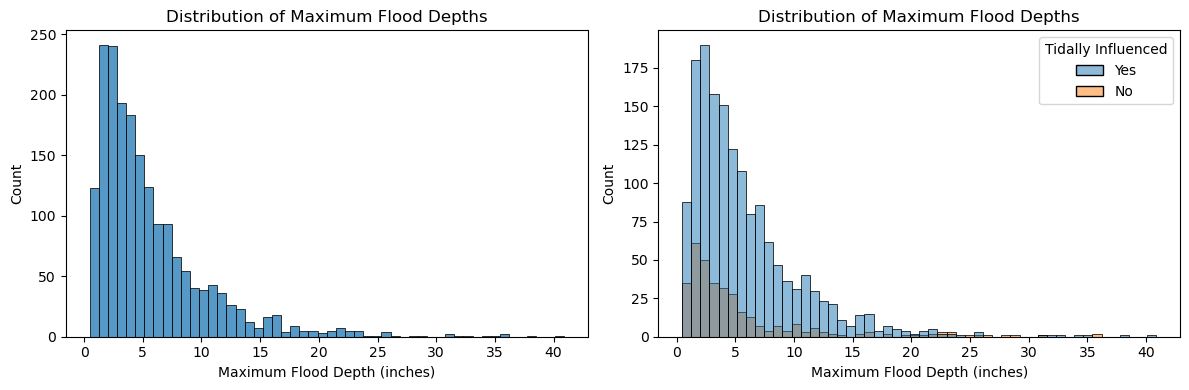

In [46]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    
sns.histplot(
    merged_df['max_depth_inches'],
    ax=axs[0]
)

axs[0].set_title('Distribution of Maximum Flood Depths')
axs[0].set_xlabel('Maximum Flood Depth (inches)')
axs[0].set_ylabel('Count')

sns.histplot(
    data=merged_df,
    x='max_depth_inches',
    hue="tidally_influenced",
    ax=axs[1])

axs[1].set_title('Distribution of Maximum Flood Depths')
axs[1].set_xlabel('Maximum Flood Depth (inches)')
axs[1].set_ylabel('Count')
axs[1].get_legend().set_title("Tidally Influenced")

fig.tight_layout()

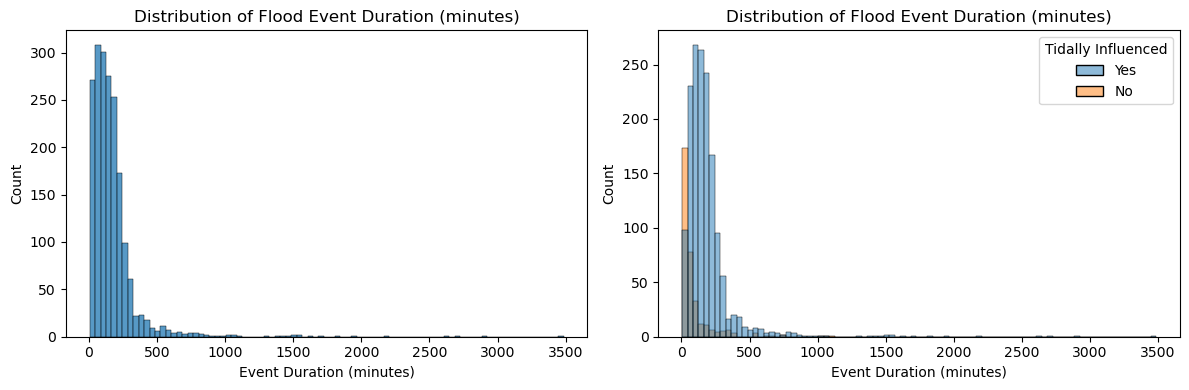

In [47]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    
sns.histplot(
    merged_df['duration_mins'],
    ax=axs[0]
)

axs[0].set_title('Distribution of Flood Event Duration (minutes)')
axs[0].set_xlabel('Event Duration (minutes)')
axs[0].set_ylabel('Count')

sns.histplot(
    data=merged_df,
    x='duration_mins',
    hue="tidally_influenced",
    ax=axs[1])

axs[1].set_title('Distribution of Flood Event Duration (minutes)')
axs[1].set_xlabel('Event Duration (minutes)')
axs[1].set_ylabel('Count')
axs[1].get_legend().set_title("Tidally Influenced")

fig.tight_layout()

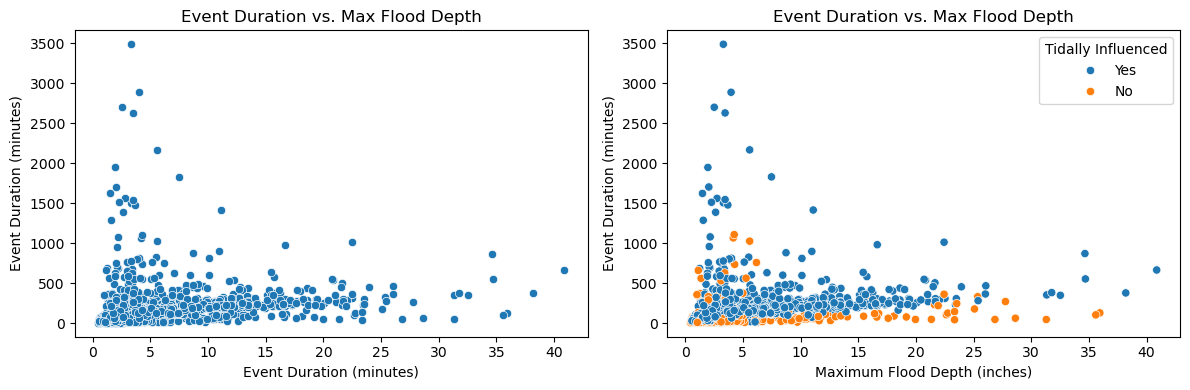

In [48]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    
sns.scatterplot(
    data=merged_df,
    x="max_depth_inches", y="duration_mins",
    ax=axs[0]
)

axs[0].set_title('Event Duration vs. Max Flood Depth')
axs[0].set_xlabel('Event Duration (minutes)')
axs[0].set_ylabel('Event Duration (minutes)')

sns.scatterplot(
    data=merged_df,
    x="max_depth_inches", y="duration_mins",
    hue="tidally_influenced",
    ax=axs[1]
)

axs[1].set_title('Event Duration vs. Max Flood Depth')
axs[1].set_xlabel('Maximum Flood Depth (inches)')
axs[1].set_ylabel('Event Duration (minutes)')
axs[1].get_legend().set_title("Tidally Influenced")

fig.tight_layout()

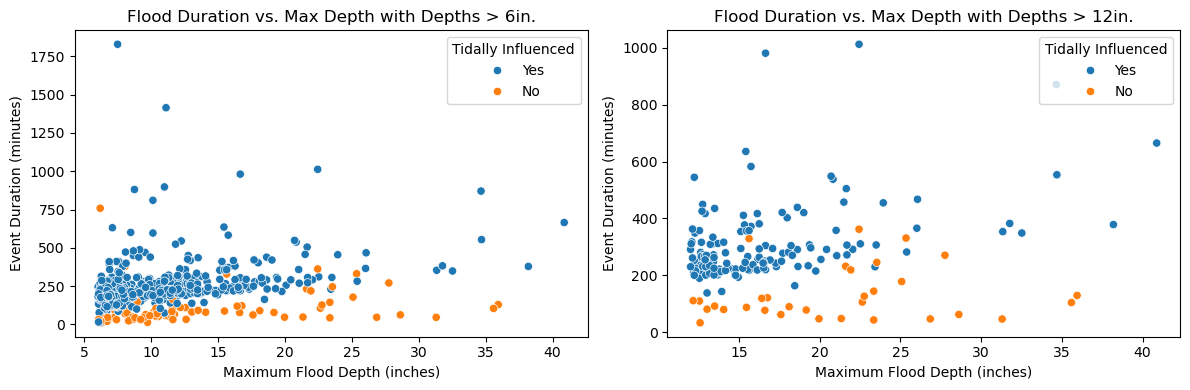

In [49]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(
    data=merged_df.filter(pl.col("max_depth_inches") > 6),
    x="max_depth_inches", y="duration_mins",
    hue="tidally_influenced",
    ax=axs[0]
)

axs[0].set_title("Flood Duration vs. Max Depth with Depths > 6in.")
axs[0].set_xlabel('Maximum Flood Depth (inches)')
axs[0].set_ylabel('Event Duration (minutes)')
axs[0].get_legend().set_title("Tidally Influenced")

sns.scatterplot(
    data=merged_df.filter(pl.col("max_depth_inches") > 12),
    x="max_depth_inches", y="duration_mins",
    hue="tidally_influenced",
    ax=axs[1]
)

axs[1].set_title("Flood Duration vs. Max Depth with Depths > 12in.")
axs[1].set_xlabel('Maximum Flood Depth (inches)')
axs[1].set_ylabel('Event Duration (minutes)')
axs[1].get_legend().set_title("Tidally Influenced")

fig.tight_layout()

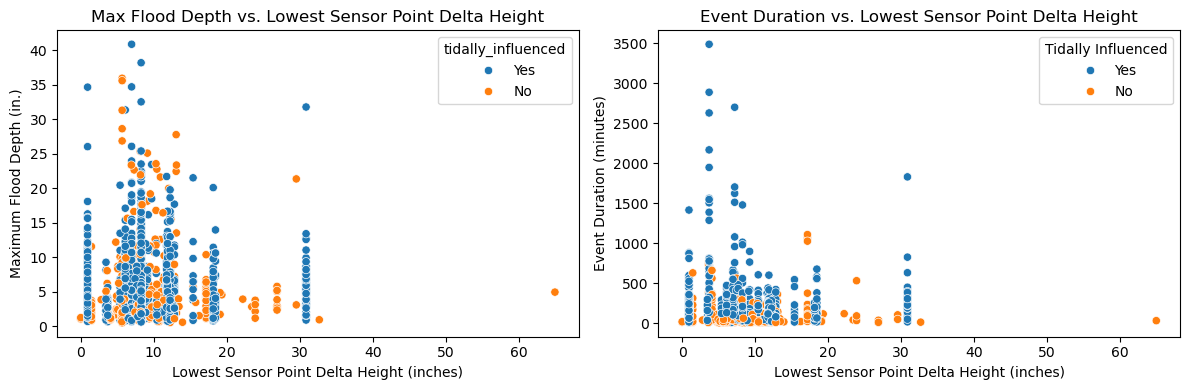

In [50]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    
sns.scatterplot(
    data=merged_df,
    x="lowest_point_height_delta_inches", y="max_depth_inches",
    hue="tidally_influenced",
    ax=axs[0]
)

axs[0].set_title('Max Flood Depth vs. Lowest Sensor Point Delta Height')
axs[0].set_xlabel('Lowest Sensor Point Delta Height (inches)')
axs[0].set_ylabel('Maximum Flood Depth (in.)')

sns.scatterplot(
    data=merged_df,
    x="lowest_point_height_delta_inches", y="duration_mins",
    hue="tidally_influenced",
    ax=axs[1]
)

axs[1].set_title('Event Duration vs. Lowest Sensor Point Delta Height')
axs[1].set_xlabel('Lowest Sensor Point Delta Height (inches)')
axs[1].set_ylabel('Event Duration (minutes)')
axs[1].get_legend().set_title("Tidally Influenced")

fig.tight_layout()

# Example Maps

In [51]:
# Recalculate the geometry column for example purposes

# generate geometry from x, y points
geometry = gpd.points_from_xy(
    merged_df['longitude'].to_pandas(),
    merged_df['latitude'].to_pandas()
)

# create geodataframe
gdf = gpd.GeoDataFrame(
    merged_df.to_pandas(),
    geometry=geometry,
    crs=4326
)

# preview data
print(f'shape of data: {gdf.shape}')
print(gdf.crs)

gdf['geometry'].head()

shape of data: (1887, 30)
EPSG:4326


0    POINT (-73.80996 40.59136)
1    POINT (-73.88104 40.81285)
2    POINT (-73.76781 40.59662)
3    POINT (-73.90585 40.88326)
4    POINT (-73.83056 40.65339)
Name: geometry, dtype: geometry

/opt/miniconda3/envs/floodnet_env/lib/python3.11/site-packages/geopandas/plotting.py:746: UserWarning: Numba not installed. Using slow pure python version.
  binning = mapclassify.classify(


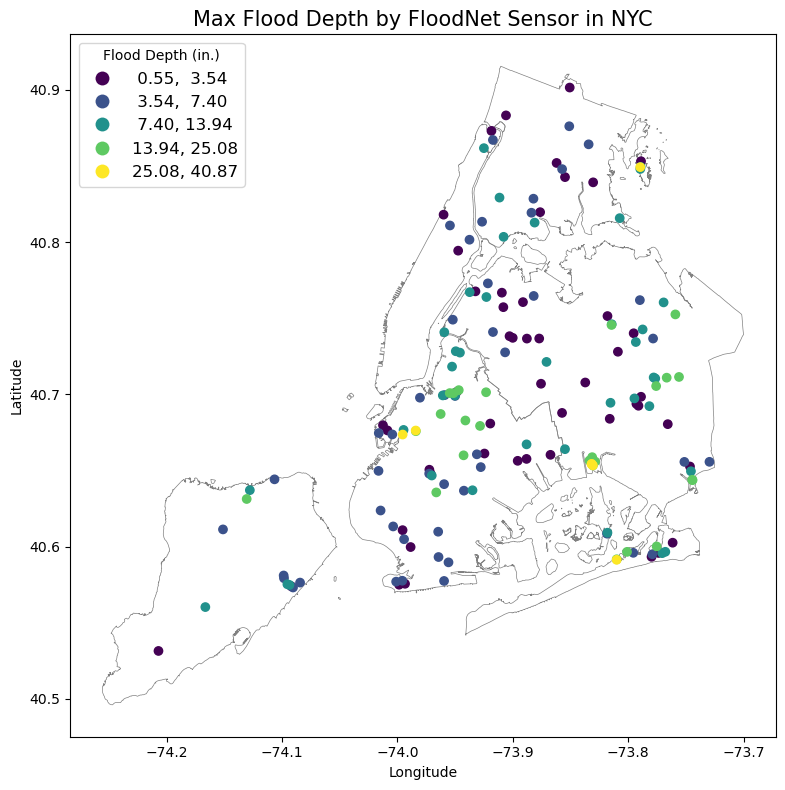

In [52]:
# create figure
fig, ax = plt.subplots(figsize=(8, 8))

# unique sensors by max flood depth
max_depth_gdf = (
    gdf.sort_values(
        by=['sensor_id', 'max_depth_inches'],
        ascending=[True, False]
    )
    .drop_duplicates(subset='sensor_name')
    # we sort again to plot the highest depths on top of neighboring points
    .sort_values(by='max_depth_inches', ascending=True)
)

# plot sensor locations with legend
max_depth_gdf.plot(
    column=max_depth_gdf['max_depth_inches'],
    scheme='FisherJenks',
    ax=ax,
    legend=True,
    legend_kwds={"title": "Flood Depth (in.)", "fontsize": "large"},
)

# borough plot
boro_gdf.plot(
    ax=ax,
    facecolor="None", linewidth=.5, edgecolor="gray",
    zorder=0
)

# aesthetics
plt.title("Max Flood Depth by FloodNet Sensor in NYC", fontsize=15)
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# tight layout
plt.tight_layout()

/opt/miniconda3/envs/floodnet_env/lib/python3.11/site-packages/geopandas/plotting.py:746: UserWarning: Numba not installed. Using slow pure python version.
  binning = mapclassify.classify(


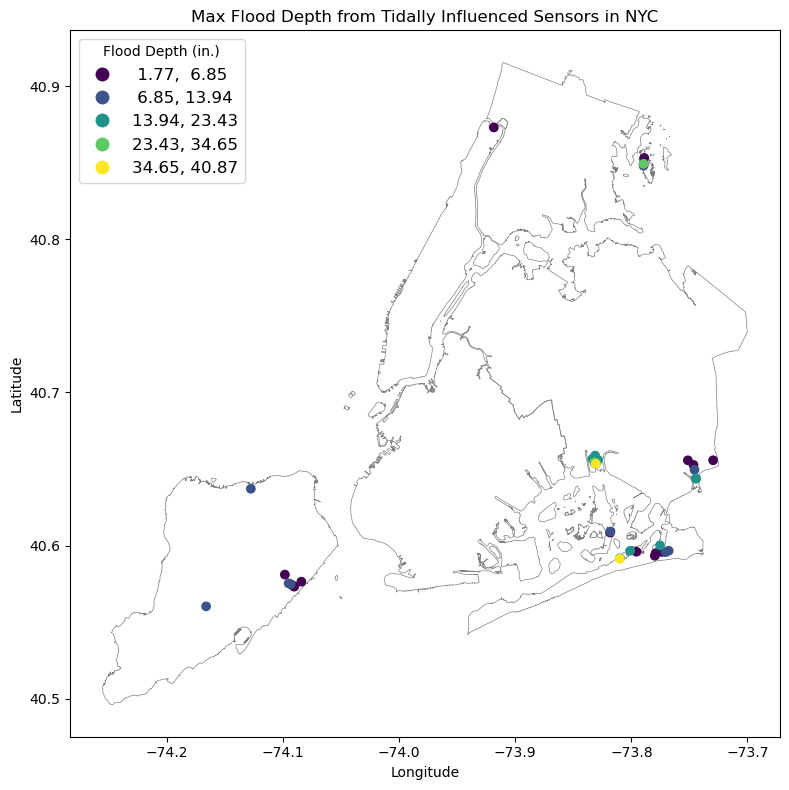

In [53]:
# create figure
fig, ax = plt.subplots(figsize=(8, 8))

# unique sensors by max flood depth
max_depth_gdf = (
    gdf.query("tidally_influenced == 'Yes'")
    .sort_values(
        by=['sensor_id', 'max_depth_inches'],
        ascending=[True, False]
    )
    .drop_duplicates(subset='sensor_name')
    # we sort again to plot the highest depths on top of neighboring points
    .sort_values(by='max_depth_inches', ascending=True)
)

# plot sensor locations with legend
max_depth_gdf.plot(
    column=max_depth_gdf['max_depth_inches'],
    scheme='FisherJenks',
    ax=ax,
    legend=True,
    legend_kwds={"title": "Flood Depth (in.)", "fontsize": "large"},
)

# borough plot
boro_gdf.plot(
    ax=ax,
    facecolor="None", linewidth=.5, edgecolor="gray",
    zorder=0
)

# aesthetics
plt.title("Max Flood Depth from Tidally Influenced Sensors in NYC", fontsize=12)
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# tight layout
plt.tight_layout()

/opt/miniconda3/envs/floodnet_env/lib/python3.11/site-packages/geopandas/plotting.py:746: UserWarning: Numba not installed. Using slow pure python version.
  binning = mapclassify.classify(


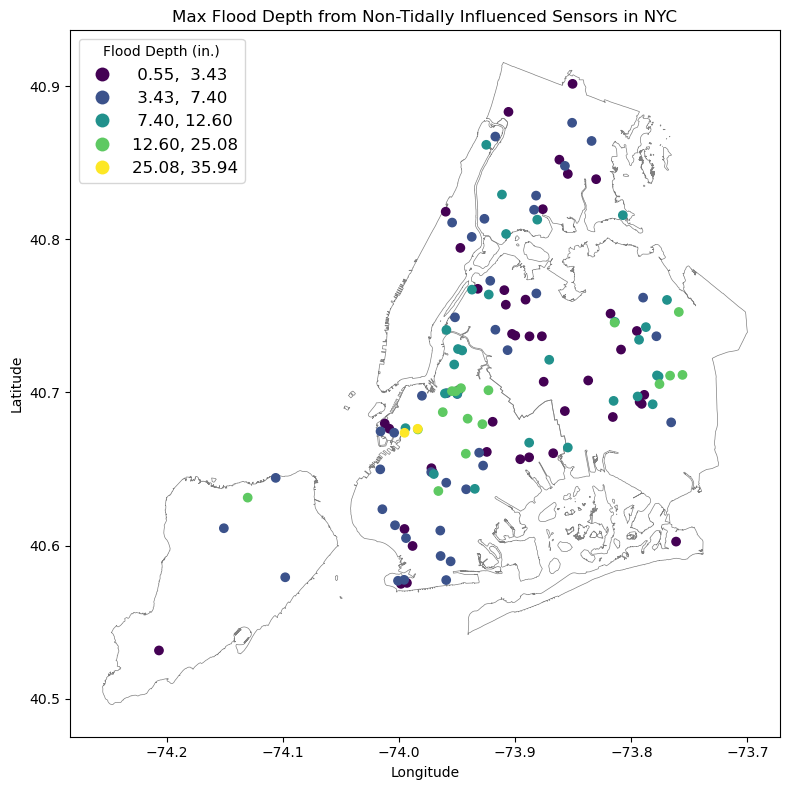

In [54]:
# create figure
fig, ax = plt.subplots(figsize=(8, 8))

# unique sensors by max flood depth
max_depth_gdf = (
    gdf.query("tidally_influenced == 'No'")
    .sort_values(
        by=['sensor_id', 'max_depth_inches'],
        ascending=[True, False]
    )
    .drop_duplicates(subset='sensor_name')
    # we sort again to plot the highest depths on top of neighboring points
    .sort_values(by='max_depth_inches', ascending=True)
)

# plot sensor locations with legend
max_depth_gdf.plot(
    column=max_depth_gdf['max_depth_inches'],
    scheme='FisherJenks',
    ax=ax,
    legend=True,
    legend_kwds={"title": "Flood Depth (in.)", "fontsize": "large", "loc": "upper left"},
)

# borough plot
boro_gdf.plot(
    ax=ax,
    facecolor="None", linewidth=.5, edgecolor="gray",
    zorder=0
)

# aesthetics
plt.title("Max Flood Depth from Non-Tidally Influenced Sensors in NYC", fontsize=12)
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# tight layout
plt.tight_layout()